### Video playback

In [2]:
## conda env: stereo_vision
import os
import cv2
import numpy as np
import pyzed.sl as sl
import matplotlib.pyplot as plt

In [3]:
# load coordinates of keypoints

input_folder = "./saved_coords"
input_file_name = "straight_walk_HD120060FPS_low_pos.avi_body06_performance.npy"

keypoint_coords = np.load(os.path.join(input_folder, input_file_name))
keypoint_coords.shape

(1522, 17, 2)

In [4]:
len(keypoint_coords)

1522

In [ ]:
zed_ankle_depths = []

# Create a ZED camera object
zed = sl.Camera()

# Set SVO path for playback
input_path = os.path.join('./stereo_videos',input_file_name.split('avi')[0]+'svo2')
input_type = sl.InputType()
input_type.set_from_svo_file(input_path)  # Set init parameter to run from the .svo
init_parameters = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

init_parameters.depth_mode = sl.DEPTH_MODE.ULTRA
init_parameters.coordinate_units = sl.UNIT.CENTIMETER  # CENTIMETER, METER, MILLIMETER
init_parameters.depth_stabilization = 75


# Open the ZED
err = zed.open(init_parameters)
framerate = zed.get_camera_information().camera_configuration.fps
resolution = zed.get_camera_information().camera_configuration.resolution



svo_depth = sl.Mat()
svo_image = sl.Mat()

svo_position = 0

while svo_position < len(keypoint_coords) and zed.grab() == sl.ERROR_CODE.SUCCESS: 

    # Get frame count
    svo_position = zed.get_svo_position()

    # get color image and depth map
    zed.retrieve_measure(svo_depth, sl.MEASURE.DEPTH)
    zed.retrieve_image(svo_image, sl.VIEW.LEFT)
    # zed.retrieve_image(svo_image, sl.VIEW.DEPTH)
    img = svo_image.get_data()
    depth_map = svo_depth.get_data()
    depth_map = np.transpose(depth_map)

    ## ankle coords
    left_ankle_x = int(keypoint_coords[svo_position, 15, 0])
    left_ankle_y = int(keypoint_coords[svo_position, 15, 1])

    right_ankle_x = int(keypoint_coords[svo_position, 16, 0])
    right_ankle_y = int(keypoint_coords[svo_position, 16, 1])

    

    # if left_ankle_x < img.shape[0] and right_ankle_x < img.shape[0] and left_ankle_y < img.shape[1] and right_ankle_y < img.shape[1]:

    depth_left_ankle = depth_map[left_ankle_x, left_ankle_y]
    depth_right_ankle = depth_map[right_ankle_x, right_ankle_y]

    zed_ankle_depths.append(np.array([depth_left_ankle, depth_right_ankle]))


    ## put markers on image for verification
    cv2.circle(img, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)
    cv2.circle(img, (right_ankle_x, right_ankle_y), 5, (0, 255, 0), 3)
    cv2.circle(img, (0,0),5,(255,0,0),3)

    # cv2.circle(depth_map, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)
    # cv2.circle(depth_map, (right_ankle_x, right_ankle_y), 5, (0, 255, 0), 3)
    # cv2.circle(depth_map, (50,100),5,(255,0,0),3)

    ## show DEPTH
    # cv2.imshow("View", cv2.resize(depth_map,(800,600)))

    ## show frame
    cv2.imshow("vid", cv2.resize(img, (800,600)))

    if cv2.waitKey(25) & 0xFF == ord("q"):
        break



cv2.destroyAllWindows()
zed.close()


zed_ankle_depths = np.array(zed_ankle_depths)
zed_ankle_depths.shape

NameError: name 'svo_position' is not defined

In [28]:
framerate, resolution.width, resolution.height

(60.0, 1920, 1200)

## Not sure why it works

In [19]:
cv2.circle(depth_map, (50,100),5,(0,0,0),3)
cv2.circle(depth_map, (50,100),10,(255,255,255),3)
cv2.circle(depth_map, (50,100),15,(0,0,0),3)
cv2.circle(depth_map, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)
cv2.circle(depth_map, (right_ankle_x, right_ankle_y), 5, (0, 255, 0), 3)
cv2.imshow('depth_map',cv2.resize(depth_map, (800,600)))
cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
print(f'camera depth: {svo_depth.get_width(),svo_depth.get_height()}')
print(f'camera image: {svo_image.get_width(),svo_image.get_height()} (widht, height)')

print(f'{depth_map.shape}')
print(f'{img.size, img.shape}')

camera depth: (1920, 1200)
camera image: (1920, 1200) (widht, height)
(1200, 1920)
(9216000, (1200, 1920, 4))


In [53]:
small_img = cv2.resize(img,(int(img.shape[1]/2),int(img.shape[0]/2)))
cv2.imshow('test',small_img)
cv2.circle(small_img, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)
cv2.circle(small_img, (right_ankle_y, right_ankle_x), 5, (0, 255, 0), 3)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [4]:
d = np.transpose(depth_map)
d.shape

(1920, 1200)

In [18]:
print(left_ankle_x, left_ankle_y, right_ankle_x, right_ankle_y)
print(depth_map.shape[1], depth_map.shape[0])
print(img.shape[1], img.shape[0])

1035 851 1277 874
1920 1200
1920 1200


## Saving & plotting output

In [57]:
out_folder = "./saved_keypoint_depth"
out_file_name = f"{input_file_name.split(".avi")[0]}_ankle_depth_cm__utlra75.npy"
np.save(
    os.path.join(out_folder,out_file_name), zed_ankle_depths
)
print(out_file_name)

straight_walk_HD120060FPS_low_pos_ankle_depth_cm__utlra75.npy


In [32]:
zed_ankle_depths = np.load(out_file_name)

In [1]:
t = np.linspace(0,len(zed_ankle_depths)-1,len(zed_ankle_depths))/framerate
plt.figure()
plt.plot(t,zed_ankle_depths)
plt.suptitle("Ankle ditance from camera [cm]")
plt.title(out_file_name.split('keypoint_depth\\')[1])
plt.legend(['left ankle','right ankle'])
plt.xticks(np.linspace(0,np.floor(t[-1]),int(np.floor(t[-1]))+1))
plt.savefig(os.path.join(out_file_name.split('.npy')[0]+'.png'))

NameError: name 'np' is not defined

In [8]:

t.shape

(1427,)

In [6]:
t = (np.linspace(0, len(zed_ankle_depths[100:300]) - 1, len(zed_ankle_depths[100:300]))/60)
t.shape
# t

(200,)

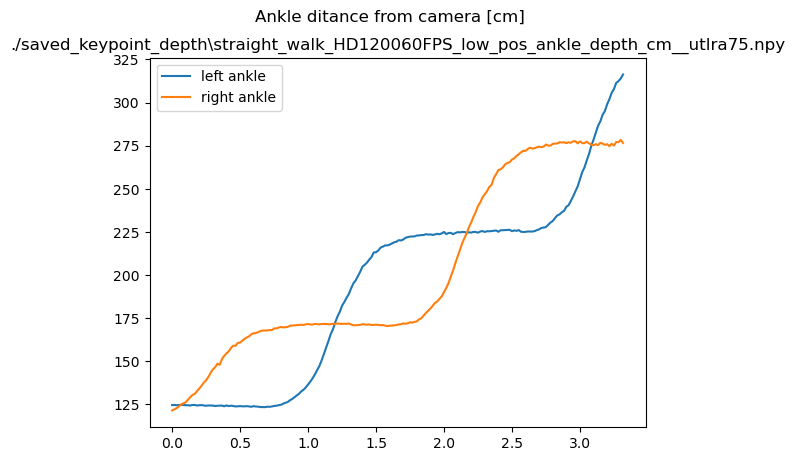

In [ ]:
t = (np.linspace(0, len(zed_ankle_depths) - 1, len(zed_ankle_depths))/60)
plt.figure()
plt.plot(t, zed_ankle_depths[100:300])
plt.suptitle("Ankle ditance from camera [cm]")
plt.title(out_file_name)
plt.legend(['left ankle','right ankle'])
# plt.plot(zed_ankle_depths)